## I. Lý thuyết Canny Edge Detector

### 1. Các bước của thuật toán Canny

Thuật toán Canny gồm 4 bước chính:

a. Giảm nhiễu (Noise Reduction)
Dùng Gaussian filter để làm mượt ảnh.
Mục đích: loại bỏ nhiễu để tránh phát hiện cạnh sai.

b. Tính gradient (Gradient Calculation)
Tính độ thay đổi cường độ sáng theo 2 hướng (x, y).
Thường dùng Sobel để tính:
Độ lớn gradient → độ mạnh cạnh
Hướng gradient → hướng cạnh

c. Non-Maximum Suppression
Làm mảnh cạnh.
Chỉ giữ lại điểm có giá trị lớn nhất theo hướng gradient.
Loại bỏ các điểm không phải cực đại → cạnh rõ nét hơn.

d. Ngưỡng kép (Double Threshold) & Theo dõi cạnh (Hysteresis)
Dùng 2 ngưỡng:

Ngưỡng cao → cạnh chắc chắn

Ngưỡng thấp → cạnh yếu

Giữ cạnh yếu nếu nó nối với cạnh mạnh → tránh mất cạnh thật.

### 2. Các tham số quan trọng
a. Sigma (Gaussian)
Sigma lớn → ảnh mượt hơn, ít nhiễu nhưng mất chi tiết
Sigma nhỏ → giữ chi tiết nhưng dễ nhiễu

b. Ngưỡng thấp & cao
Ảnh hưởng trực tiếp đến số lượng cạnh:
Ngưỡng thấp → nhiều cạnh (kể cả nhiễu)
Ngưỡng cao → ít cạnh (có thể mất chi tiết)

### 3. Ưu điểm & ứng dụng
Ưu điểm:
Phát hiện cạnh chính xác
Giảm nhiễu tốt
Cạnh mảnh, rõ

Nhược điểm:
Nhạy với tham số
Tốn thời gian hơn Sobel/Laplacian
Ứng dụng:
Xử lý ảnh y tế
Nhận dạng vật thể
Computer vision (xe tự lái, AI)

## II. Bài tập thực hành

In [4]:
import cv2 
import matplotlib.pyplot as plt
import numpy as np

In [5]:
img_org = cv2.imread('/home/tuong/Courses/CV/opencv-learning/flower_new.png')
# Convert BGR to RGB
img = cv2.cvtColor(img_org, cv2.COLOR_BGR2RGB)

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def display_images(*images, titles=None, max_cols=5):
    num_images = min(len(images), 12)  # Giới hạn tối đa 10 ảnh
    
    if num_images == 0:
        print("No images to display.")
        return
    
    # Tính toán số hàng và cột
    cols = min(num_images, max_cols)
    rows = (num_images + cols - 1) // cols
    
    # Tạo figure
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    
    # Ép kiểu axes thành mảng 1 chiều để dễ truy vấn trong vòng lặp
    if num_images == 1:
        axes = np.array([axes])
    else:
        axes = axes.flatten()
        
    for i in range(num_images):
        img = images[i]
        
        # Kiểm tra nếu là ảnh xám (2D) hoặc ảnh màu (3D)
        if len(img.shape) == 2:
            axes[i].imshow(img, cmap='gray')
        else:
            axes[i].imshow(img)
            
        # Thiết lập tiêu đề
        title = titles[i] if titles and i < len(titles) else f"Image {i+1}"
        axes[i].set_title(title)
        axes[i].axis('off')
    
    # Ẩn các ô subplot dư thừa nếu có
    for i in range(num_images, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

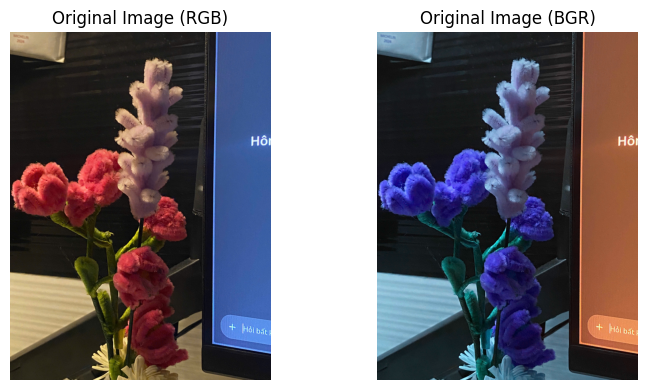

In [7]:
display_images(img, img_org, titles=["Original Image (RGB)", "Original Image (BGR)"])

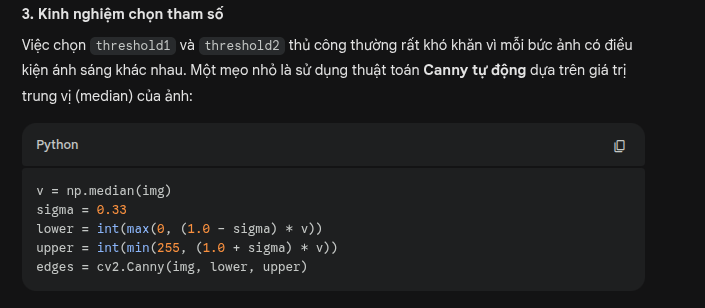

## 1. Thực hiện thuật toán Canny bằng các thư viện

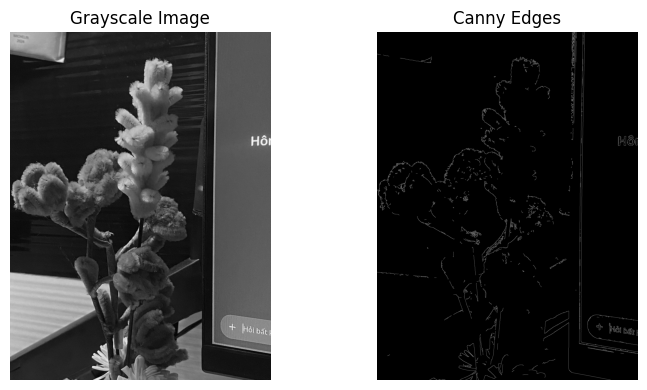

In [ ]:
# Dùng CV2
gray_img = cv2.cvtColor(img_org, cv2.COLOR_BGR2GRAY)
# dùng tt canny 
low_threshold = 100
high_threshold = 200
edges = cv2.Canny(gray_img, low_threshold, high_threshold)
display_images(gray_img, edges, titles=["Grayscale Image", "Canny Edges"])

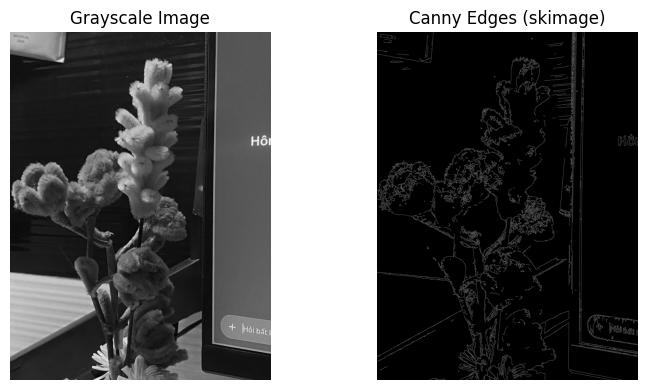

In [9]:
#dùng scikit-image 
from skimage import feature
edges_skimage = feature.canny(gray_img, sigma=1.2)
display_images(gray_img, edges_skimage, titles=["Grayscale Image", "Canny Edges (skimage)"])

## 2 Thay đổi tham số và quan sát kết quả

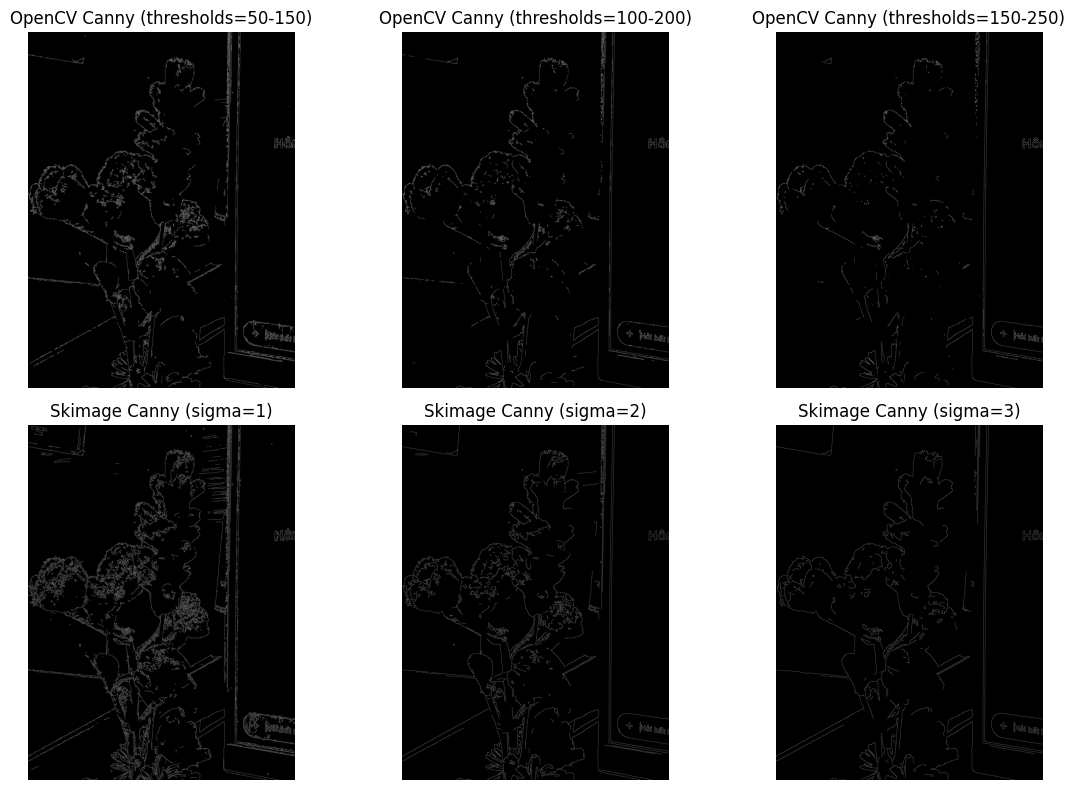

In [10]:
"""
Chạy OpenCV với nhiều bộ threshold:
(50, 150)
(100, 200)
(150, 250)
Chạy Scikit-image với nhiều sigma:
1
2
3
"""
thresholds = [(50, 150), (100, 200), (150, 250)]
sigmas = [1, 2, 3]
canny_edges_opencv = [cv2.Canny(gray_img, low, high) for low, high in thresholds]
canny_edges_skimage = [feature.canny(gray_img, sigma=s) for s in sigmas]

# Hiển thị kết quả
titles_opencv = [f"OpenCV Canny (thresholds={low}-{high})" for low, high in thresholds]
titles_skimage = [f"Skimage Canny (sigma={s})" for s in sigmas]
display_images(*canny_edges_opencv, *canny_edges_skimage, titles=titles_opencv + titles_skimage, max_cols=3)

### Sau khi thực hiện thuật toán Canny bằng OpenCV và Scikit-image với các tham số khác nhau, có thể rút ra một số nhận xét như sau:

Hai thư viện sử dụng các tham số khác nhau (OpenCV dùng ngưỡng thấp/cao, Scikit-image dùng sigma), do đó không thể so sánh trực tiếp giá trị tham số mà cần so sánh dựa trên kết quả đầu ra.

Với OpenCV:
Khi tăng ngưỡng (threshold), số lượng cạnh phát hiện được giảm, ảnh ít nhiễu hơn nhưng có thể làm mất các chi tiết nhỏ.
Khi giảm ngưỡng, phát hiện được nhiều cạnh hơn nhưng dễ xuất hiện nhiễu.

Với Scikit-image:
Khi sigma nhỏ, ảnh giữ được nhiều chi tiết nhưng dễ bị nhiễu.
Khi sigma lớn, ảnh mượt hơn, ít nhiễu nhưng làm mất các cạnh yếu.

So sánh tổng thể:
OpenCV cho kết quả nhanh và kiểm soát cạnh rõ ràng thông qua ngưỡng.
Scikit-image cho kết quả mượt hơn nhờ quá trình làm trơn (Gaussian smoothing).
Khi điều chỉnh tham số phù hợp, cả hai phương pháp đều cho kết quả tương đối giống nhau.

Kết luận:
Việc lựa chọn tham số phù hợp là yếu tố quan trọng quyết định chất lượng phát hiện cạnh.
Không có bộ tham số tối ưu chung cho mọi ảnh, cần điều chỉnh tùy theo đặc điểm ảnh đầu vào.

## 3 Áp dụng canny với các loại ảnh khác nhau 

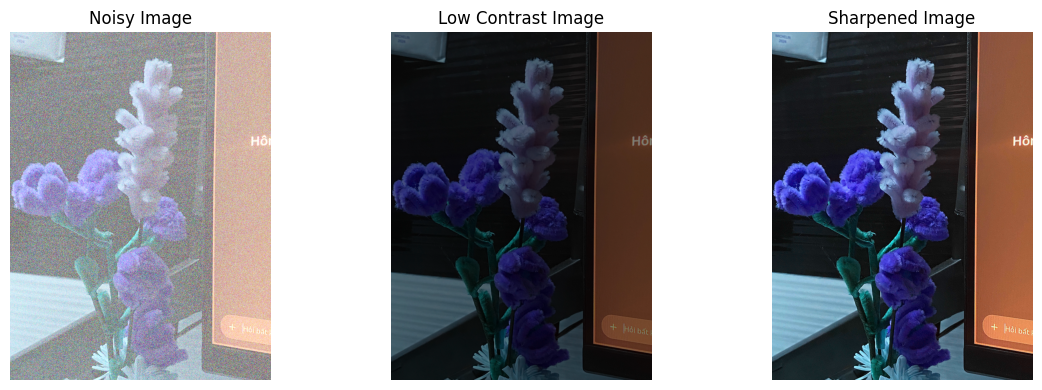

In [11]:
# Biến ảnh gốc thành các dạng ảnh khác nhau(ảnh nhiễu, ảnh có độ tương phản thấp, ảnh có nhiều chi tiết)

# Thêm nhiễu Gaussian
noise = np.random.normal(0, 25, img_org.shape).astype(np.uint8)
noisy_img = cv2.add(img_org, noise)
# Giảm độ tương phản
alpha = 0.5  # Hệ số giảm độ tương phản
low_contrast_img = cv2.convertScaleAbs(img_org, alpha=alpha, beta=0)
# Tăng chi tiết 
sharpen_kernel = np.array([[0, -1, 0], [-1, 5,-1], [0, -1, 0]])
sharpened_img = cv2.filter2D(img_org, -1, sharpen_kernel)
# Hiển thị các ảnh đã biến đổi
display_images(noisy_img, low_contrast_img, sharpened_img, titles=["Noisy Image", "Low Contrast Image", "Sharpened Image"], max_cols=3)



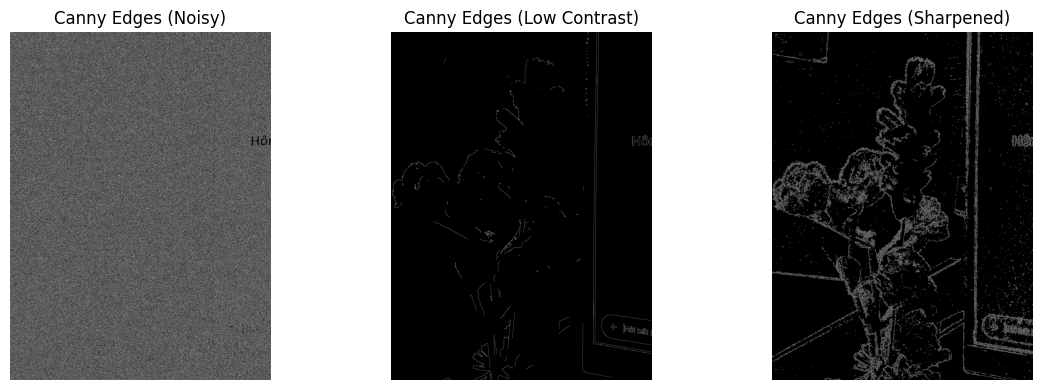

In [12]:
# áp dụng canny edge detection cho các ảnh đã biến đổi
edges_noisy = cv2.Canny(noisy_img, low_threshold, high_threshold)
edges_low_contrast = cv2.Canny(low_contrast_img, low_threshold, high_threshold)
edges_sharpened = cv2.Canny(sharpened_img, low_threshold, high_threshold)
# Hiển thị kết quả
display_images(edges_noisy, edges_low_contrast, edges_sharpened, titles=["Canny Edges (Noisy)", "Canny Edges (Low Contrast)", "Canny Edges (Sharpened)"], max_cols=3)


- Ảnh nhiễu (noisy):
    - Canny dễ nhận thêm nhiều cạnh giả từ nhiễu.
    - Thường thấy nhiều chi tiết “cạnh” nhỏ, rối.
    - Cách khắc phục: Gaussian blur lên trước, hoặc tăng `low_threshold`/`high_threshold`.

- Ảnh độ tương phản thấp:
    - Cạnh yếu, suy giảm độ rõ, dễ bị bỏ sót (mất cạnh thật) nếu ngưỡng quá cao.
    - Nên tăng tương phản/chuẩn hóa (histogram equalization) trước khi Canny.
    - Có thể dùng ngưỡng thấp hơn hoặc `sigma` nhỏ hơn (skimage) để giữ cạnh.

- Ảnh nhiều chi tiết:
    - Canny cho nhiều cạnh, đôi khi “quá tải”, khó phân biệt cạnh chính/ké.
    - Nên lọc contour theo diện tích/độ dài, chọn khu vực quan trọng.
    - Kết hợp tiền xử lý như giữ nét (sharpen) hoặc làm mượt nhẹ giúp giảm bớt nhiễu cạnh nhỏ.

Tóm lại: Canny hiệu quả nhất khi tiền xử lý phù hợp (làm mượt với nhiễu, tăng tương phản với ảnh xám, điều chỉnh ngưỡng/sigma), và sau đó lọc đầu ra để lấy cạnh mục tiêu.

## 4 Kết hợp Canny với các kỹ thuật khác 

In [ ]:
img = cv2.imread("/home/tuong/Courses/CV/opencv-learning/img_test.png")

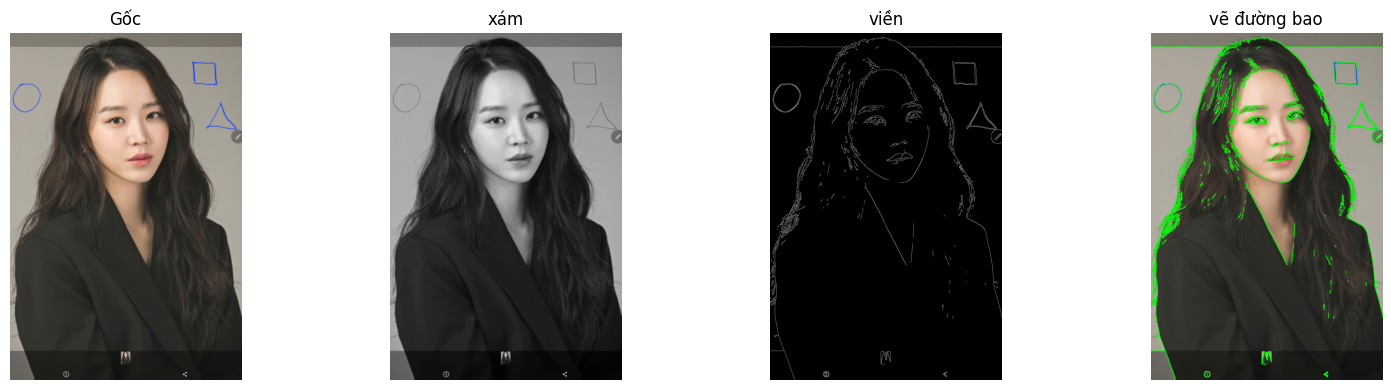

In [56]:
# preprocessing image 
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_copy = img.copy()

blurG = cv2.GaussianBlur(img_gray, (5, 5),0)

# tìm viền bằng canny
edged = cv2.Canny(blurG, 50, 70)

#tìm đường bao(Contours)
# cv2.RETR_EXTERNAL: Chỉ lấy các đường bao ngoài cùng
# cv2.CHAIN_APPROX_SIMPLE: Nén các điểm thừa để tiết kiệm bộ nhớ
contours, hierarchy = cv2.findContours(edged, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE) 

# vẽ lại đường bao tìm được bằng nét xanh lên ảnh gốc
cv2.drawContours(img_copy, contours, -1, (0, 255, 0), 2)

display_images(img, blurG, edged, img_copy, titles=["Gốc","xám","viền","vẽ đường bao"])
 

In [57]:
print(f"Tim thay tong cong: {len(contours)} doi tuong.")

Tim thay tong cong: 523 doi tuong.


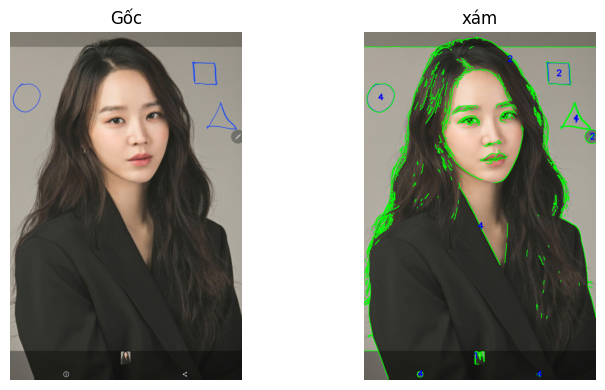

In [62]:
# Định nghĩa bảng tra cứu số thứ tự (Mapping)
# 1: Tam giác, 2: Hình vuông/Chữ nhật, 3: Hình tròn (hoặc đa giác nhiều cạnh)
shape_map = {3: "1", 4: "2"}

for cnt in contours:
    # Lọc bỏ các nhiễu quá nhỏ (diện tích < 100 pixel)
    if cv2.contourArea(cnt) < 100:
        continue

    # 3. Xấp xỉ đa giác
    peri = cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, 0.04 * peri, True)
    num_vertices = len(approx)

    # Xác định nhãn số
    label = "0" # Mặc định nếu không khớp
    if num_vertices == 3:
        label = "1" # Tam giác
    elif num_vertices == 4:
        label = "2" # Hình vuông/Chữ nhật
    elif num_vertices > 8:
        label = "3" # Hình tròn (nhiều đỉnh xấp xỉ)
    else:
        label = "4" # Các đa giác khác (ngũ giác, lục giác...)

    # 4. Tính tâm đối tượng để ghi số
    M = cv2.moments(cnt)
    if M["m00"] != 0:
        cX = int(M["m10"] / M["m00"])
        cY = int(M["m01"] / M["m00"])

        # Vẽ đường bao và ghi số chú thích
        cv2.drawContours(img_copy, [cnt], -1, (0, 255, 0), 2)
        cv2.putText(img_copy, label, (cX - 10, cY + 10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 3)

display_images(img, img_copy, titles=["Gốc","xám","viền","vẽ đường bao"])